In [1]:
import numpy as np
import astropy.units as u
from astropy.units import Quantity
import astropy.constants as const
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.time import Time
from scipy import integrate
import pandas as pd
from sparse import COO
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from lmfit.lineshapes import gaussian

from pathlib import Path
import itertools
import warnings

from cosipy.response import FullDetectorResponse, DetectorResponse, PointSourceResponse
from cosipy import UnBinnedData, BinnedData
from FullDetectorResponseNew import FullDetectorResponse
from DetectorResponseNew import DetectorResponse
from cosipy.spacecraftfile import SpacecraftFile
from cosipy import test_data

from histpy import Histogram, Axes, Axis, HealpixAxis
import mhealpy as hp
from mhealpy import HealpixMap, HealpixBase
from scoords import Attitude, SpacecraftFrame

from threeML import Model, Powerlaw, Gaussian, Constant, Band
from tqdm import tqdm

from astromodels import PointSource
from threeML import PluginPrototype, Model, JointLikelihood, DataList

import copy
# from cosipy import COSILike

DATA_DIR = Path('/Users/penguin/Documents/Grad School/Research/COSI/COSIpy/docs/DC3/')
response_path = DATA_DIR / 'data/responses/DC2-Continuum_N-149_17-11-2024_14-32.imagingresponse_nside8.area.h5'
# response_path = DATA_DIR / 'data/responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse_nside8.area.good_chunks.h5'

13:51:58 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=962951;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=415395;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=962663;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=947042;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=842794;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=99619;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=755869;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=595495;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

13:51:59 WARNING   No fermitools installed                                              ]8;id=291328;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=36567;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=54897;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=391714;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=581711;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=111385;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=603182;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=637727;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
pix = 0

with FullDetectorResponse.open(response_path) as f:
    print(f.__dict__)
    nside = f.nside
    # print(f._axes['NuLambda'].edges)
    dr = f[pix]

{'_file': <HDF5 file "DC2-Continuum_N-149_17-11-2024_14-32.imagingresponse_nside8.area.h5" (mode r)>, '_drm': <HDF5 group "/DRM" (3 members)>, '_unit': Unit("cm2"), '_sparse': True, '_axes': <histpy.axes.Axes object at 0x11553aa40>, '_pix_rangesets': None, '_pix_rangesets_argsort': None, '_uniq': None, '_scheme': 'RING', '_order': 3, '_coordsys': <SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>, '_npix_ratio_max': 4503599627370496}


In [25]:
dr.project('Ei').contents.todense() / (dr.get_effective_area().contents.value+1e-12)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1.])

In [3]:
from threeML.plugin_prototype import PluginPrototype
from threeML.utils.statistics.likelihood_functions import poisson_log_likelihood_ideal_bkg

class COSILikeNew(PluginPrototype):

    def __init__(self, name, dr2, exposure_time, energy_samples, spectrum_unit, nuisance_param):
        super().__init__(name, nuisance_param)  # Or 'extended' if needed
        self._dr2 = dr2
        self._exposure_time = exposure_time.to('s')
        self._energy_samples = energy_samples
        self._spectrum_unit = spectrum_unit
        self._observed_events = energy_samples  # These are your Em samples
        self._n_observed = len(energy_samples)

    def set_model(self, likelihood_model):
        self._likelihood_model = likelihood_model

    def _compute_predicted_a(self):
        # Insert your final aj calculation loop here, using:
        # - self._likelihood_model.spectrum.main.shape(self._likelihood_model.parameters)
        # - self._dr2
        # - self._energy_samples
        # Return a numpy array of aj[j] values
        Eaxis = self._dr2.axes['Ei']
        spectrum = self._likelihood_model.source.spectrum.main.shape

        aj = []
        for Em in tqdm(self._energy_samples):
            rate_func = lambda E: spectrum(E.value) * self._spectrum_unit * self._dr2.get_interp_response({'Ei': E, 'Em': Em})
            idx = np.searchsorted(Eaxis.centers, Em, side='right')
            offsetter = Em / Eaxis.centers[idx-1] #Em / Eaxis.centers[idx]
            integral = sum(rate_func(Ei) * dE for Ei, dE in zip(Eaxis.centers * offsetter, Eaxis.widths * offsetter)) * self._exposure_time.to('s')       # Riemann sum approximation * exposure_time.to('s')       # Riemann sum approximation
            aj.append(integral)

        aj = Quantity(aj)
        return aj

    def _compute_predicted_c(self):
        Eaxis = self._dr2.axes['Ei']
        Epsedges = self._dr2.axes['Eps'].edges        # Can't densify further as get_interp_response only outputs (99,) shaped array
        Epscenters = (Epsedges[:-1] + Epsedges[1:]) / 2

        Eiedges = Eaxis.edges # densify_array(Eaxis.edges, k=1) * u.keV
        spectrum = self._likelihood_model.source.spectrum.main.shape

        integral = 0
        for Ei_low, Ei_high in zip(Eiedges[:-1], Eiedges[1:]):
            Ei = (Ei_low + Ei_high) / 2
            rate_func = spectrum(Ei.value) * self._spectrum_unit * (Ei_high - Ei_low) * self._exposure_time.to('s')

            Em = self._dr2.transform_Eps_to_Em(Epscenters, Ei)
            Em_high = self._dr2.transform_Eps_to_Em(Epsedges[1:], Ei)
            Em_low = self._dr2.transform_Eps_to_Em(Epsedges[:-1], Ei)

            integral += rate_func * np.sum(self._dr2.get_interp_response({'Ei': Ei}) * (Em_high - Em_low)) / Ei      # The denominator is the Jacobian term discussed in 20240924-ResponseRelativeCoordinates-cosipy-Israel.pdf page 7 when integrating over dEm instead of dEps (R is in Eps coordinates). dEps / dEm = 1/Ei
            
        c = integral
        return c

    def get_log_like(self):
        aj = self._compute_predicted_a()
        c = self._compute_predicted_c()
        log_like = -c + np.sum(np.log(aj + 1e-12))
        return log_like

    def inner_fit(self):
        return -2.0 * self.get_log_like()  # 3ML minimizes -2 logL

    def get_number_of_data_points(self):
        return self._n_observed

    def get_number_of_model_parameters(self):
        return self._likelihood_model.get_number_of_free_parameters()

In [3]:
def get_all_interp_weights(dr, target: dict):
    indices = []
    weights = []

    for label in dr.axes.labels:

        if label == 'Ei':
            key = label

        elif label == 'Eps':
            key = 'Em'

        elif label == 'Phi':
            key = label

        elif label == 'Theta':
            # label = 'ThetaZeta'
            axis_type = 'Axis'      # Theta, Zeta have axis_type = 'Axis'. PsiChi axis_type = 'HealpixAxis'

            # NuLambda_sc = np.array([0])         # Placeholder. FullDetectorResponse object depends on NuLambda. Detector Response object does not. 
            # I/O with radians not degrees
            Theta, Zeta = transform_PsiChi_to_ThetaZeta(target['Phi'].to(u.rad).value, \
                                                 target['Psi_sc'].to(u.rad).value, target['Chi_sc'].to(u.rad).value)        # target['Ei', 'Em'] do not matter as we are throwing away the spectral component returned bu the function. 
            
            Theta = Theta * u.rad
            Zeta = Zeta * u.rad
            print(Theta, Zeta)

            # Theta axis
            idx, w = dr.axes['Theta'].interp_weights(Theta)
            indices.append(idx.reshape(-1))
            weights.append(w.reshape(-1))

            # Zeta axis
            idx, w = dr.axes['Zeta'].interp_weights(Zeta)
            indices.append(idx.reshape(-1))
            weights.append(w.reshape(-1))

            continue
    
        elif label == 'Zeta':
            continue

        else:
            raise ValueError(f'Label: {label} is not supported')
        
        axis = dr.axes[label]

        axis_scale = axis._scale
        axis_type = str(type(axis)).split('.')[-1].strip("'>")      # XXX: Could probably be simplified using `isinstance()`

        # Scale
        if axis_scale in ['linear', 'log']:   # To ensure nonlinear binning parametrizations are converted to a linear scale.

            # Axis Type
            if axis_type in ['Axis', 'HealpixAxis']:

                if key == 'Ei':
                    idx, w = axis.interp_weights(target[key])

                elif key == 'Em':
                    centers = dr.transform_Eps_to_Em(axis.centers, target['Ei'])      # Transform coordinates to more physical units      # TODO: Generalize this
                    absdiff = np.abs(centers - target[key])                             # Calculate absolute difference to given target
                    idx = np.argpartition(absdiff, (1,2))[:2]                               # Find indices corresponding to two smallest absdiff
                    w = 1 - np.partition(absdiff, (1,2))[:2] / (centers[1] - centers[0])    # Calculate weights corresponding to two smallest absdiff

                elif key == 'Phi':
                    idx, w = axis.interp_weights(target[key])

            else:
                raise ValueError(f'Axis type: {axis_type} is not supported')

        else:
            raise ValueError(f'{axis_scale} binning / scale scheme is not supported')
        
        indices.append(idx)
        weights.append(w)
    
    return (indices, weights)

def get_interp_response(dr, target: dict):
    """
    Currently only supports nonlinear spectral responses (
    and for a particular parametrization)
    TODO: In the future, this will also support nonlinear / 
    piecewise-linear directional responses.
    """

    # target = dict(sorted(target.items()))       # Sort dictionary by key (XXX: assuming response matrix also sorts in the same way)
    indices, weights = get_all_interp_weights(dr, target)
    perm_indices = list(itertools.product(*indices))
    perm_weights = list(itertools.product(*weights))

    if len(target) == len(dr.axes):
        pass
    else:
        warnings.warn('len(target) != len(dr.axes)')
    
    interpolated_response_value = 0
    for idx, w in zip(perm_indices, perm_weights):
        interpolated_response_value += np.prod(w) * dr.contents[idx]
    
    return interpolated_response_value

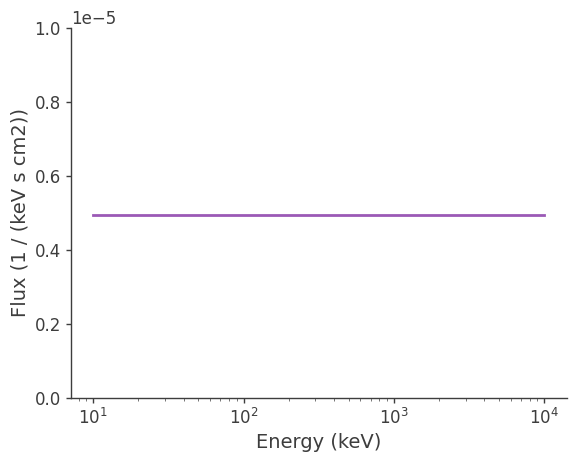

In [3]:
# Define Constant Flux Model (for Crab)
F = 4.95e-6 / u.cm / u.cm / u.keV / u.s

spectrum = Constant()
spectrum.k.value = F.value
spectrum.k.min_value = F.value / 1e4
spectrum.k.max_value = F.value * 1e4
spectrum.k.unit = F.unit
spectrum_unit = spectrum.k.unit

spectrum.k.free = True

# Generate some data for plotting
xdata = np.linspace(dr.axes['Ei'].edges[0], dr.axes['Ei'].edges[-1], 401)
ydata = spectrum(xdata.value) * spectrum_unit

# Plot the compound model
plt.plot(xdata, ydata)
plt.xlabel(f'Energy ({xdata.unit})')
plt.ylabel(f'Flux ({F.unit})')
plt.ylim([0, 1e-5])
plt.xscale('log')
plt.show()

15:12:33 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=745355;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=506378;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

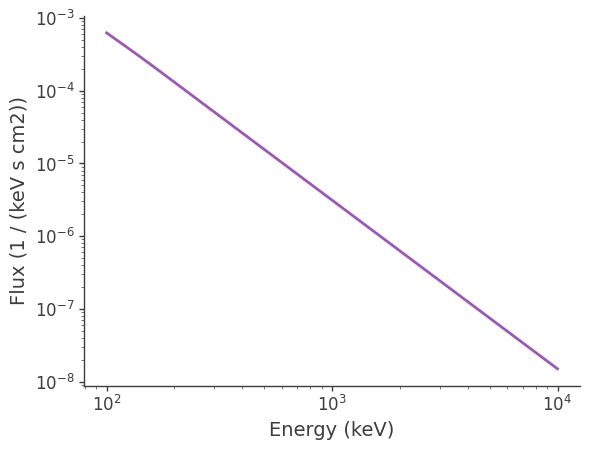

In [14]:
def spectrum_reset(spectrum):
    spectrum.alpha.min_value = -2.14
    spectrum.alpha.max_value = 3.0
    spectrum.beta.min_value = -5.0
    spectrum.beta.max_value = -2.15
    spectrum.xp.min_value = 1.0

    spectrum.alpha.value = alpha_inj
    spectrum.beta.value = beta_inj
    spectrum.xp.value = xp_inj.value
    spectrum.K.value = K_inj.value
    spectrum.piv.value = piv_inj.value

    spectrum.xp.unit = xp_inj.unit
    spectrum.K.unit = K_inj.unit
    spectrum.piv.unit = piv_inj.unit

    return spectrum

alpha_inj = -1.99
beta_inj = -2.32
E0_inj = 531. * (alpha_inj - beta_inj) * u.keV
xp_inj = E0_inj * (alpha_inj + 2) / (alpha_inj - beta_inj)
piv_inj = 100. * u.keV
K_inj = 7.56e-4 / u.cm / u.cm / u.s / u.keV

spectrum = Band()

spectrum = spectrum_reset(spectrum)

spectrum_unit = spectrum.K.unit

# Generate some data for plotting
xdata = np.geomspace(100, 10000, 201) * u.keV
ydata = spectrum(xdata.value) * spectrum_unit

# Plot the compound model
plt.plot(xdata, ydata)
plt.xlabel(f'Energy ({xdata.unit})')
plt.ylabel(f'Flux ({K_inj.unit})')
# plt.ylim([0, 1e-5])
plt.xscale('log')
plt.yscale('log')
plt.show()

In [5]:
point_source = UnBinnedData(DATA_DIR / '511/inputs.yaml')
# data = point_source.get_dict_from_fits(DATA_DIR / 'Crab/sources/Crab_Flat_Spectrum_3months_unbinned_data_filtered_with_SAAcut.fits')
data = point_source.get_dict_from_fits(DATA_DIR / 'Crab/sources/crab_standard_3months_unbinned_data_filtered_with_SAAcut.fits')     # Data is already cut below 100 keV

idx = data['Energies'] < 10**3.25
data['Energies'] = data['Energies'][idx]

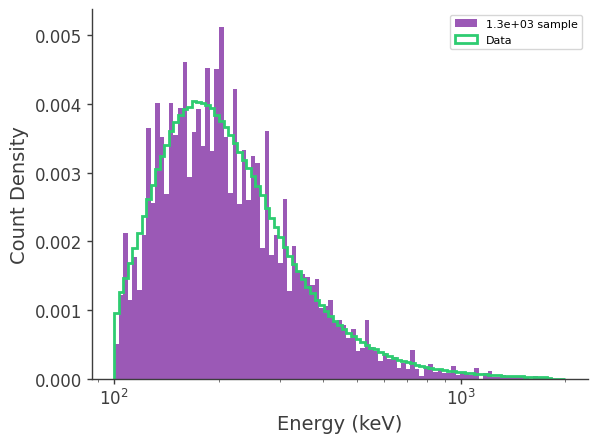

In [27]:
num_samples = 1300
bins = np.logspace(2, 3.3, 100)*u.keV
energy_samples = np.random.choice(data['Energies'], num_samples, replace=False) * u.keV

plt.hist(energy_samples, bins=bins, density=True, label=f'{num_samples:.1e} sample')
plt.hist(data['Energies'], bins=bins.value, density=True, lw=2, histtype='step', label='Data')
plt.xlabel('Energy (keV)')
plt.ylabel('Count Density')
plt.legend()
plt.xscale('log')

In [28]:
exposure_time = 100*92.3 * u.d * (len(energy_samples) / len(data['Energies'])) * 5/6 * 1/4      # Fudge factor, 3 month total, SAA cut, 25% FOV

hist = dr.project('Ei', 'Eps').slice[19:, :]
dr2 = DetectorResponse(coord = dr.coord, edges=hist.axes, contents=hist.contents, unit=dr.unit)
Aeff = dr2.get_effective_area

In [29]:
cosi = COSILikeNew('cosi',                                                     # COSI 3ML plugin
                 dr2 = dr2,                                                     # detector response
                 exposure_time = exposure_time,
                 energy_samples = energy_samples,
                 spectrum_unit = spectrum_unit,
                 nuisance_param = {}                                            # background parameter)       
)   

target_coord = SkyCoord.from_name('Crab').galactic
source = PointSource('source', 
                     l = target_coord.l.value,
                     b = target_coord.b.value,
                     spectral_shape = spectrum)
model = Model(source)
cosi.set_model(model)

In [30]:
cosi_spectrum = cosi._likelihood_model.source.spectrum.main.shape
cosi_spectrum = spectrum_reset(spectrum=cosi_spectrum)

logL_values = []
prefactor_values = np.geomspace(K_inj/10, K_inj*100, 16)
for K_value in prefactor_values:
    cosi._likelihood_model.source.spectrum.main.shape.K.value = K_value
    logL_values.append(cosi.get_log_like())

100%|██████████| 1300/1300 [00:19<00:00, 67.11it/s]


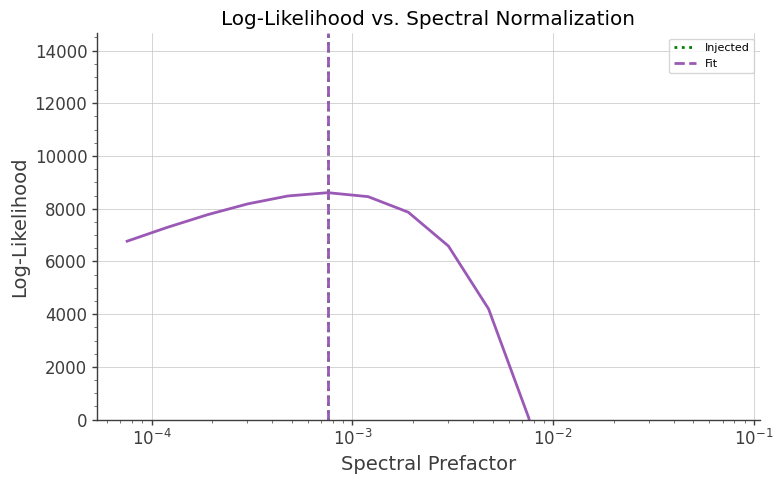

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(prefactor_values, logL_values, lw=2)
plt.xscale('log')
plt.xlabel("Spectral Prefactor")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood vs. Spectral Normalization")
plt.axvline(K_inj.value, ls=':', c='g', label='Injected')
plt.axvline(prefactor_values[np.argmax(logL_values)].value, ls='--', label='Fit')
# plt.axhline(np.max(logL_values), ls='--', label='Fit')
plt.legend()
plt.ylim(bottom=0)
plt.minorticks_on()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
cosi_spectrum.beta

Parameter beta = -2.32 []
(min_value = -5.0, max_value = -2.15, delta = 0.2, free = True)

In [34]:
cosi_spectrum = cosi._likelihood_model.source.spectrum.main.shape
cosi_spectrum = spectrum_reset(spectrum=cosi_spectrum)

logL_values = []
values = np.linspace(-2.4, -2.2, 11)
for beta in values:
    cosi_spectrum.beta.value = beta
    logL_values.append(cosi.get_log_like())

100%|██████████| 1300/1300 [00:19<00:00, 67.00it/s]


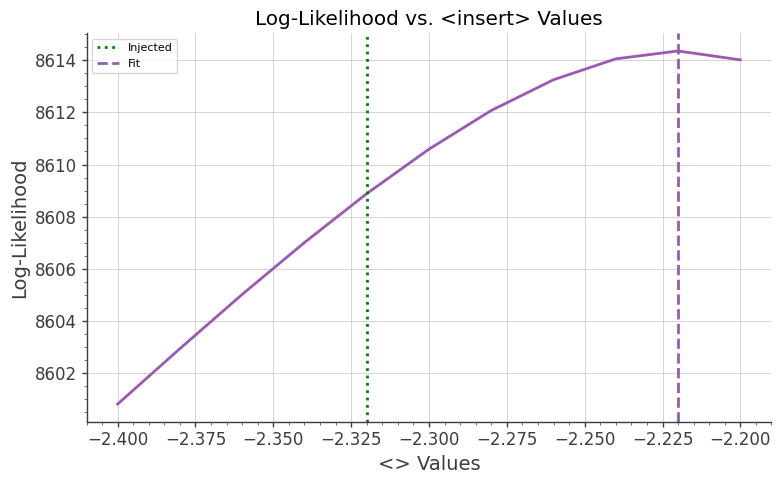

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(values, logL_values, lw=2)
# plt.xscale('log')
plt.xlabel("<> Values")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood vs. <insert> Values")
plt.axvline(beta_inj, ls=':', c='g', label='Injected')
plt.axvline(values[np.nanargmax(logL_values)], ls='--', label='Fit')
# plt.axhline(np.max(logL_values), ls='--', label='Fit')
plt.legend()
# plt.ylim(bottom=0)
plt.minorticks_on()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit()

15:08:44 INFO      set the minimizer to minuit                                             ]8;id=926721;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=316567;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

  0%|          | 0/1000 [00:00<?, ?it/s]
WARNING RuntimeWarning: overflow encountered in _pow


WARNING RuntimeWarning: invalid value encountered in multiply


WARNING RuntimeWarning: overflow encountered in _pow


WARNING RuntimeWarning: invalid value encountered in multiply


WARNING RuntimeWarning: overflow encountered in _pow


WARNING RuntimeWarning: invalid value encountered in multiply


WARNING RuntimeWarning: overflow encountered in _pow


WARNING RuntimeWarning: invalid value encountered in multiply


WARNING RuntimeWarning: overflow encountered in _pow


WARNING RuntimeWarning: invalid value encountered in multiply


WARNING RuntimeWarning: overflow encountered in _pow


WARNING RuntimeWarning: overflow encountered in _pow


WARNING RuntimeWarning: overflow encountered in _pow


WARNING RuntimeWarning: overflow encountered in _pow


WARNING RuntimeWarning: overflow encountered in _pow


WARNING RuntimeWarning: overflow encountered in _pow


WARNING RuntimeWarning: overflow e

15:47:51 WARNING   These parameters returned a logLike = Nan: [979.49481871  -1.96779021   ]8;id=867426;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=595674;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1005\1005]8;;\
                  0.          -4.99888196]                                                                         

100%|██████████| 1000/1000 [00:15<00:00, 65.62it/s]


08:49:54 ERROR     Last status:                                                             ]8;id=278521;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=226986;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/minimizer/minuit_minimizer.py#166\166]8;;\

...

         ERROR     │ 1 │ source_spectrum_main_Band_alpha │  -1.9889  │  0.0000   │          ]8;id=417365;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=723742;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/minimizer/minuit_minimizer.py#174\174]8;;\
                  │            │  -2.14  │    3    │       │                                                       

         ERROR     │ 2 │ source_spectrum_main_Band_xp    │ 7.0149e-7 │ 0.0000e-7 │          ]8;id=316644;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=940106;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/minimizer/minuit_minimizer.py#174\174]8;;\
                  │            │    0    │         │       │                                                       

         ERROR     │ 3 │ source_spectrum_main_Band_beta  │  -4.8989  │  0.0000   │          ]8;id=825997;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=512116;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/minimizer/minuit_minimizer.py#174\174]8;;\
                  │            │   -5    │  -2.15  │       │                                                       

         ERROR     └───┴─────────────────────────────────┴───────────┴───────────┴───────── ]8;id=606026;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=998078;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/minimizer/minuit_minimizer.py#174\174]8;;\
                  ───┴────────────┴─────────┴─────────┴───────┘                                                    

FitFailed: MIGRAD call failed. This is usually due to unconstrained parameters.

(<Axes: xlabel='Ei [keV]', ylabel='Eps'>,
 <matplotlib.collections.QuadMesh at 0x2d73f5de0>)

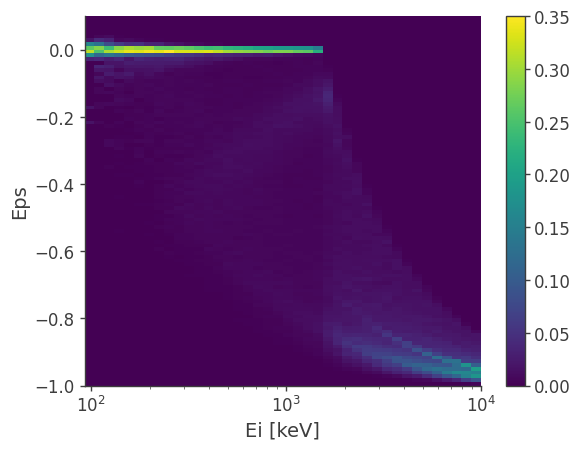

In [8]:
dr2.get_dispersion_matrix().plot()
# plt.xlim(right=2e3)

In [28]:
Em = 1650 * u.keV
rate_func = lambda E: spectrum(E.value) * spectrum_unit * dr2.get_interp_response({'Ei': E, 'Em': Em})
# Eaxis = dr2.project('Ei').rebin(1).axes['Ei']
Eaxis = dr2.axes['Ei']

idx = np.searchsorted(Eaxis.centers, Em, side='right')
offsetter = Em / Eaxis.centers[idx-1] #Em / Eaxis.centers[idx]
integral = sum(rate_func(Ei) * dE for Ei, dE in zip(Eaxis.centers * offsetter, Eaxis.widths * offsetter)) * exposure_time.to('s')       # Riemann sum approximation * exposure_time.to('s')       # Riemann sum approximation
integral

<Quantity 7.44886158e-05>

In [118]:
spectrum.K.value = K_inj.value
spectrum.xp.value = xp_inj #/ 5

In [113]:
Eaxis = dr2.axes['Ei']

aj = []
for Em in tqdm(energy_samples):
    rate_func = lambda E: spectrum(E.value) * spectrum_unit * dr2.get_interp_response({'Ei': E, 'Em': Em})
    idx = np.searchsorted(Eaxis.centers, Em, side='right')
    offsetter = Em / Eaxis.centers[idx-1] #Em / Eaxis.centers[idx]
    integral = sum(rate_func(Ei) * dE for Ei, dE in zip(Eaxis.centers * offsetter, Eaxis.widths * offsetter)) * exposure_time.to('s')       # Riemann sum approximation * exposure_time.to('s')       # Riemann sum approximation
    aj.append(integral)

aj = Quantity(aj)

# If spectrum is not normalized or if dr2.get_interp_response(...) isn't properly normalized over Em, 
# then the integral won't yield a valid probability density, and your log-likelihood will be off in scale. 
# You might want to precompute a full normalization constant:

np.sum(np.log(aj + 1e-12))

100%|██████████| 1000/1000 [00:14<00:00, 68.63it/s]


<Quantity 6829.07018832>

In [119]:
Eaxis = dr2.axes['Ei']
Epsedges = dr2.axes['Eps'].edges        # Can't densify further as get_interp_response only outputs (99,) shaped array
Epscenters = (Epsedges[:-1] + Epsedges[1:]) / 2

Eiedges = Eaxis.edges # densify_array(Eaxis.edges, k=1) * u.keV

integral = 0
for Ei_low, Ei_high in zip(Eiedges[:-1], Eiedges[1:]):
    Ei = (Ei_low + Ei_high) / 2
    rate_func = spectrum(Ei.value) * spectrum_unit * (Ei_high - Ei_low) * exposure_time.to('s')

    Em = dr2.transform_Eps_to_Em(Epscenters, Ei)
    Em_high = dr2.transform_Eps_to_Em(Epsedges[1:], Ei)
    Em_low = dr2.transform_Eps_to_Em(Epsedges[:-1], Ei)

    integral += rate_func * np.sum(dr2.get_interp_response({'Ei': Ei}) * (Em_high - Em_low)) / Ei      # The denominator is the Jacobian term discussed in 20240924-ResponseRelativeCoordinates-cosipy-Israel.pdf page 7 when integrating over dEm instead of dEps (R is in Eps coordinates). dEps / dEm = 1/Ei
    
c = integral
c

<Quantity 985.7628128>

In [115]:
np.sum(np.log(aj + 1e-12)) - c

<Quantity 6247.94090839>

In [ ]:
np.sum(np.log(aj + 1e-12)) - c

<Quantity 6372.75752724>

In [47]:
Eiedges = Eaxis.edges # densify_array(Eaxis.edges, k=1) * u.keV
expected_counts = np.sum([
    spectrum(E.value) * spectrum_unit * dr2.get_effective_area(E) * dE * exposure_time.to('s')
    for E, dE in zip((Eiedges[:-1]+Eiedges[1:])/2, np.diff(Eiedges))
])
expected_counts

887.187128345674

In [117]:
aj/c

<Quantity [2.66678462e+00, 2.68258133e+00, 2.44435848e+00, 1.91834996e+00,
           2.51499155e+00, 9.52289356e-01, 9.27902113e-01, 2.68790738e+00,
           2.64545799e+00, 5.96450479e-01, 1.72509090e+00, 2.59721599e+00,
           2.54588516e+00, 2.63764156e+00, 4.12617261e-01, 1.32974612e+00,
           1.88277240e+00, 1.95058685e+00, 2.31073172e+00, 7.91869730e-01,
           1.51845529e+00, 2.49069320e+00, 1.90166875e+00, 1.78388528e+00,
           2.59925398e+00, 1.76454163e+00, 2.22206916e+00, 1.57795928e+00,
           2.21215833e+00, 2.32618359e+00, 2.35206683e+00, 1.96784612e+00,
           1.93293938e+00, 2.37850335e+00, 2.66672137e+00, 2.55290388e+00,
           1.42098832e+00, 2.65915158e+00, 2.49336072e+00, 1.72874468e+00,
           2.06274935e+00, 2.24802663e+00, 2.49721630e+00, 1.98601643e+00,
           2.56836700e-01, 9.33627842e-01, 2.38314923e+00, 2.48198961e+00,
           2.46974197e+00, 7.53449733e-01, 2.60598439e+00, 8.92664766e-01,
           2.72902022e+00

In [24]:
def densify_array(centers, k):
    centers = np.asarray(centers)
    new_points = [
        np.linspace(start, end, k, endpoint=False) 
        for start, end in zip(centers[:-1], centers[1:])
    ]
    # Add the last original point
    new_points.append([centers[-1]])
    return np.concatenate(new_points)

In [ ]:
# Example usage
centers = Eaxis.centers
dense_centers = densify_array(centers, k=4) * u.keV
dense_centers

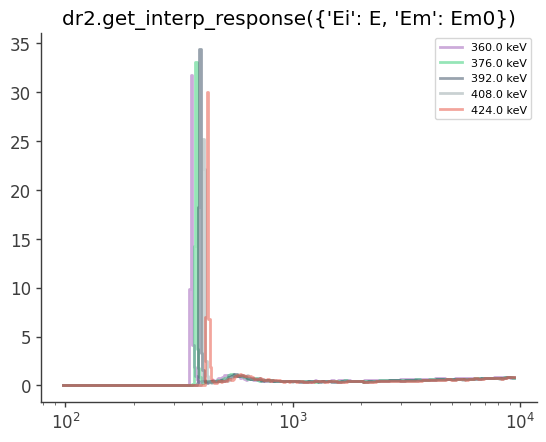

In [80]:
for Em0 in np.arange(360, 440, 16) * u.keV:
    centers = Eaxis.centers #+ Em0 - 399.66*u.keV
    # centers = centers[centers > 0]
    dense_centers = densify_array(centers, k=8) * u.keV
    plt.step(dense_centers, Quantity([dr2.get_interp_response({'Ei': E, 'Em': Em0}) for E in dense_centers]), label=f'{Em0}', alpha=0.5)
plt.xscale('log')
plt.title("dr2.get_interp_response({'Ei': E, 'Em': Em0})")
plt.legend()